In [ ]:
# ============================================
# Experiment 1 - Baseline 1D CNN 
# ============================================

In [84]:
import mltrainer
assert mltrainer.__version__ >= "0.2.5"

from mads_datasets.base import BaseDatastreamer
from mltrainer.preprocessors import BasePreprocessor
from pathlib import Path
from torch import nn
import torch

import torch
from torch import nn
import torch.optim as optim

from src import datasets, metrics


In [85]:
# Open config file
import tomllib

datadir = Path('../data')
configfile = Path("config.toml")

with configfile.open('rb') as f:
    config = tomllib.load(f)
print(config)

{'ptb': 'heart', 'arrhythmia': 'heart_big'}


In [86]:
# Dataloader
trainfile = datadir / (config['arrhythmia'] + '_train.parq')
testfile = datadir / (config['arrhythmia'] + '_test.parq')
trainfile, testfile

traindataset = datasets.HeartDataset1D(trainfile, target="target")
testdataset = datasets.HeartDataset1D(testfile, target="target")
traindataset, testdataset

(Heartdataset (len 87554), Heartdataset (len 21892))

In [87]:
# data streamer
trainstreamer = BaseDatastreamer(traindataset, preprocessor = BasePreprocessor(), batchsize=32)
teststreamer = BaseDatastreamer(testdataset, preprocessor = BasePreprocessor(), batchsize=32)
len(trainstreamer), len(teststreamer)

(2736, 684)

In [88]:
trainloader = trainstreamer.stream()

x, y = next(iter(trainloader))

print(x.shape)
print(y.shape)

torch.Size([32, 192, 1])
torch.Size([32])


In [89]:
# simpele 1D CNN
class CNN1D(nn.Module):
    def __init__(
        self,
        features: int = 1,
        num_classes: int = 5,
        kernel_size: int = 5,
        filters: int = 16,
        input_size: int = 192,
    ) -> None:
        super().__init__()

        self.num_classes = num_classes
        self.kernel_size = kernel_size
        self.filters = filters
        self.input_size = input_size

        self.convolutions = nn.Sequential(
            nn.Conv1d(
                in_channels=features,
                out_channels=filters,
                kernel_size=kernel_size,
                stride=1,
                padding=2,
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        # 192 meetpunten worden na pooling 96 meetpunten (de helft)
        flatten_size = filters * (input_size // 2)

        self.dense = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_size, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Dataset geeft is vorm (batch, 192, 1)
        # Conv1d verwacht (batch, 1, 192) dus omdraaien
        
        x = x.permute(0, 2, 1)

        x = self.convolutions(x)
        logits = self.dense(x)

        return logits

In [90]:
# Kijken of het model werkt met een batch van de dataloader
model = CNN1D(
    num_classes=5,
    filters=16,
    input_size=192,
)

# 1 batch 
x, y = next(iter(trainloader))

# evaluatiemodus
model.eval()

# geen gradients berekenen, want er is geen training
with torch.no_grad():
    output = model(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)
print("Target shape:", y.shape)

Input shape: torch.Size([32, 192, 1])
Output shape: torch.Size([32, 5])
Target shape: torch.Size([32])


In [91]:
# Metrics 
f1micro = metrics.F1Score(average='micro')
f1macro = metrics.F1Score(average='macro')
precision = metrics.Precision('micro')
recall = metrics.Recall('macro')
accuracy = metrics.Accuracy()
metrics_list = [f1micro, f1macro, precision, recall, accuracy]

In [92]:
from mltrainer import ReportTypes, Trainer, TrainerSettings
import torch
from torch import nn

# Baseline 1D CNN model
model = CNN1D(
    num_classes=5,
    filters=16,
    input_size=192,
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam

# een vijfde van de batches gebruiken voor eerste experimenten
train_steps = len(trainstreamer) // 5
valid_steps = len(teststreamer) // 5

settings = TrainerSettings(
    epochs=3,
    metrics=[
        accuracy,
        f1micro,
        f1macro,
        precision,
        recall,
    ],
    logdir="logs/baseline_1d",
    train_steps=train_steps,
    valid_steps=valid_steps,
    reporttypes=[ReportTypes.TENSORBOARD],
    earlystop_kwargs=None,
)

trainer = Trainer(
    model=model,
    settings=settings,
    loss_fn=loss_fn,
    optimizer=optimizer,
    traindataloader=trainstreamer.stream(),
    validdataloader=teststreamer.stream(),
    scheduler=optim.lr_scheduler.ReduceLROnPlateau
)

trainer.loop()

2026-07-15 12:16:36.039 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to logs/baseline_1d/20260715-121636
100%|██████████| 547/547 [00:02<00:00, 255.92it/s]
2026-07-15 12:16:39.664 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.4386 test 0.3573 metric ['0.8899', '0.8899', '0.5240', '0.8899', '0.5303']
100%|██████████| 547/547 [00:02<00:00, 261.03it/s]
2026-07-15 12:16:43.232 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.3253 test 0.2972 metric ['0.9177', '0.9177', '0.6482', '0.9177', '0.6605']
100%|██████████| 547/547 [00:02<00:00, 263.67it/s]
2026-07-15 12:16:46.794 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.2774 test 0.2788 metric ['0.9242', '0.9242', '0.6799', '0.9242', '0.6835']
100%|██████████| 3/3 [00:10<00:00,  3.58s/it]


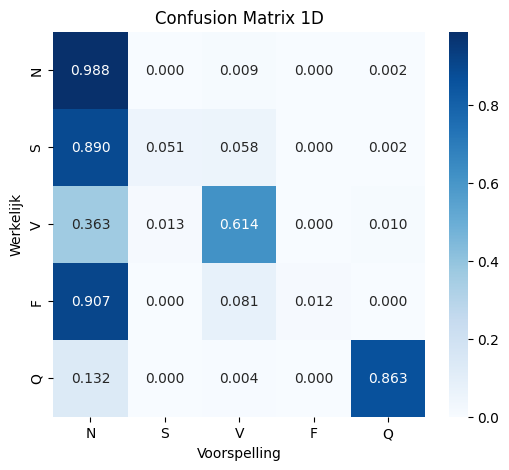


Recall per klasse
N: 0.988
S: 0.051
V: 0.614
F: 0.012
Q: 0.863


In [93]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, recall_score

model.eval()

y_true = []
y_pred = []

testdata = teststreamer.stream()

with torch.no_grad():
    for _ in range(len(teststreamer)):
        X, y = next(testdata)

        predictions = model(X).argmax(dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

# Confusion matrix
cfm = confusion_matrix(y_true, y_pred)

# Normaliseer per rij (diagonaal = recall)
cfm = cfm / cfm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))

sns.heatmap(
    cfm,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=["N", "S", "V", "F", "Q"],
    yticklabels=["N", "S", "V", "F", "Q"],
)

plt.xlabel("Voorspelling")
plt.ylabel("Werkelijk")
plt.title("Confusion Matrix 1D")
plt.show()

# Recall per klasse
classes = ["N", "S", "V", "F", "Q"]

recalls = recall_score(y_true, y_pred, average=None)

print("\nRecall per klasse")
for cls, recall in zip(classes, recalls):
    print(f"{cls}: {recall:.3f}")

In [ ]:
# ============================================
# Experiment 2 - 1D CNN met class weights
# ============================================

In [101]:
class_counts = torch.bincount(traindataset.y)

class_weights = class_counts.sum() / (
    len(class_counts) * class_counts.float()
)

print(class_weights)

tensor([ 0.2416,  7.8771,  3.0254, 27.3179,  2.7229])


In [102]:
loss_fn = nn.CrossEntropyLoss(
    weight=class_weights
)

In [103]:
classes = ["N", "S", "V", "F", "Q"]

for cls, count, weight in zip(classes, class_counts, class_weights):
    print(f"{cls}: count={count}, weight={weight:.3f}")

N: count=72471, weight=0.242
S: count=2223, weight=7.877
V: count=5788, weight=3.025
F: count=641, weight=27.318
Q: count=6431, weight=2.723


In [104]:
accuracy_metric = metrics.Accuracy()
f1micro_metric = metrics.F1Score(average="micro")
f1macro_metric = metrics.F1Score(average="macro")
precision_metric = metrics.Precision("micro")
recall_metric = metrics.Recall("macro")

In [105]:
from mltrainer import ReportTypes, Trainer, TrainerSettings
import torch.optim as optim

model = CNN1D(
    num_classes=5,
    filters=16,
    input_size=192,
)

# Gewogen lossfunctie
loss_fn = nn.CrossEntropyLoss(
    weight=class_weights,
)

optimizer = torch.optim.Adam

train_steps = len(trainstreamer) // 5
valid_steps = len(teststreamer) // 5

settings = TrainerSettings(
    epochs=3,
    metrics=[
        accuracy_metric,
        f1micro_metric,
        f1macro_metric,
        precision_metric,
        recall_metric,
    ],
    logdir="logs/weighted_1d",
    train_steps=train_steps,
    valid_steps=valid_steps,
    reporttypes=[ReportTypes.TENSORBOARD],
    earlystop_kwargs=None,
)

trainer = Trainer(
    model=model,
    settings=settings,
    loss_fn=loss_fn,
    optimizer=optimizer,
    traindataloader=trainstreamer.stream(),
    validdataloader=teststreamer.stream(),
    scheduler=optim.lr_scheduler.ReduceLROnPlateau,
)

trainer.loop()

2026-07-15 12:21:28.780 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to logs/weighted_1d/20260715-122128
100%|██████████| 547/547 [00:02<00:00, 267.87it/s]
2026-07-15 12:21:32.340 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 1.0309 test 0.8794 metric ['0.6057', '0.6057', '0.3955', '0.6057', '0.6662']
100%|██████████| 547/547 [00:01<00:00, 282.76it/s]
2026-07-15 12:21:35.759 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.7704 test 0.6795 metric ['0.7344', '0.7344', '0.4466', '0.7344', '0.7343']
100%|██████████| 547/547 [00:02<00:00, 242.68it/s]
2026-07-15 12:21:39.504 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.6835 test 0.6622 metric ['0.7702', '0.7702', '0.5252', '0.7702', '0.7742']
100%|██████████| 3/3 [00:10<00:00,  3.57s/it]


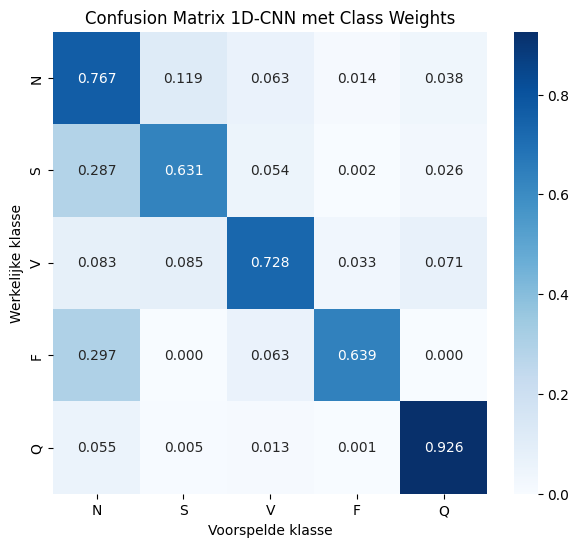


Recall per klasse:
N: 0.767
S: 0.631
V: 0.728
F: 0.639
Q: 0.926


In [107]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import confusion_matrix, recall_score

# evaluatie
model.eval()

y_true = []
y_pred = []

testdata = teststreamer.stream()

with torch.no_grad():
    for _ in range(len(teststreamer)):
        X, y = next(testdata)

        output = model(X)
        predictions = output.argmax(dim=1)

        y_true.extend(y.numpy())
        y_pred.extend(predictions.numpy())

# Confusion matrix berekenen
cfm = confusion_matrix(y_true, y_pred)

# Normaliseren per werkelijke klasse
cfm = cfm.astype(float) / cfm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cfm,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=["N", "S", "V", "F", "Q"],
    yticklabels=["N", "S", "V", "F", "Q"],
)

plt.xlabel("Voorspelde klasse")
plt.ylabel("Werkelijke klasse")
plt.title("Confusion Matrix 1D-CNN met Class Weights")

plt.show()

# Recall per klasse
classes = ["N", "S", "V", "F", "Q"]

recalls = recall_score(
    y_true,
    y_pred,
    average=None,
)

print("\nRecall per klasse:")

for cls, r in zip(classes, recalls):
    print(f"{cls}: {r:.3f}")